In [1]:
# I load the dataset and check its basic structure

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

# I keep the display wider so large tables are easier to inspect
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

# Dataset path
data_path = r"C:\Users\DELL\Downloads\Fraud.csv"

# Load the dataset
df = pd.read_csv(data_path)

print("Dataset loaded successfully.")
print("Shape of the dataset:", df.shape)

print("\nFirst 5 rows:")
display(df.head())

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes)

print("\nBasic dataset information:")
df.info()

Dataset loaded successfully.
Shape of the dataset: (6362620, 11)

First 5 rows:


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0



Column names:
['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud']

Data types:


step                int64
type               object
amount            float64
nameOrig           object
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest           object
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
isFlaggedFraud      int64
dtype: object


Basic dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [2]:
# I check data quality and the fraud class imbalance

print("Missing values in each column:")
missing_values = df.isna().sum().sort_values(ascending=False)
display(missing_values)

print("\nTotal missing values:", df.isna().sum().sum())

print("\nDuplicate rows:")
duplicate_count = df.duplicated().sum()
print(duplicate_count)

print("\nTarget variable distribution:")
fraud_counts = df["isFraud"].value_counts().sort_index()
fraud_percent = df["isFraud"].value_counts(normalize=True).sort_index() * 100

target_summary = pd.DataFrame({
    "Count": fraud_counts,
    "Percentage": fraud_percent.round(4)
})

target_summary.index = ["Legitimate transaction", "Fraudulent transaction"]
display(target_summary)

print("\nTransaction type distribution:")
type_summary = df["type"].value_counts().to_frame(name="Count")
type_summary["Percentage"] = (df["type"].value_counts(normalize=True) * 100).round(2)
display(type_summary)

print("\nFraud cases by transaction type:")
fraud_by_type = pd.crosstab(df["type"], df["isFraud"], margins=True)
fraud_by_type.columns = ["Legitimate", "Fraud", "Total"]
fraud_by_type["Fraud rate (%)"] = (fraud_by_type["Fraud"] / fraud_by_type["Total"] * 100).round(4)
display(fraud_by_type)

print("\nSystem flagged fraud distribution:")
flag_summary = pd.crosstab(df["isFlaggedFraud"], df["isFraud"], margins=True)
display(flag_summary)

Missing values in each column:


step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64


Total missing values: 0

Duplicate rows:
0

Target variable distribution:


,Count,Percentage
Legitimate transaction,6354407,99.8709
Fraudulent transaction,8213,0.1291



Transaction type distribution:


,Count,Percentage
type,,
CASH_OUT,2237500,35.17
PAYMENT,2151495,33.81
CASH_IN,1399284,21.99
TRANSFER,532909,8.38
DEBIT,41432,0.65



Fraud cases by transaction type:


,Legitimate,Fraud,Total,Fraud rate (%)
type,,,,
CASH_IN,1399284,0,1399284,0.0000
CASH_OUT,2233384,4116,2237500,0.1840
DEBIT,41432,0,41432,0.0000
PAYMENT,2151495,0,2151495,0.0000
TRANSFER,528812,4097,532909,0.7688
All,6354407,8213,6362620,0.1291



System flagged fraud distribution:


isFraud,0,1,All
isFlaggedFraud,,,
0,6354407,8197,6362604
1,0,16,16
All,6354407,8213,6362620


Saved: fraud_detection_outputs\figure_1_target_class_distribution.png


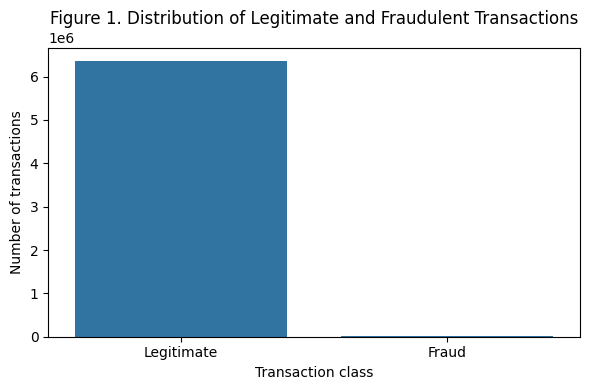

Saved: fraud_detection_outputs\figure_2_transaction_type_distribution.png


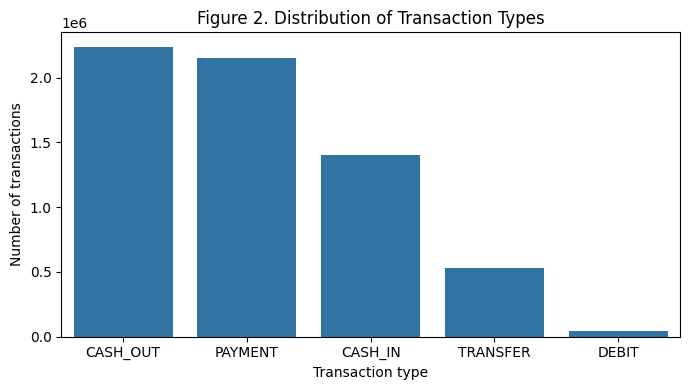

Saved: fraud_detection_outputs\figure_3_fraud_by_transaction_type.png


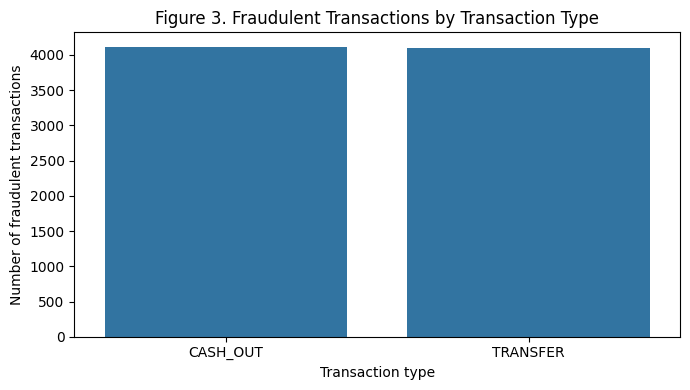

Saved: fraud_detection_outputs\figure_4_fraud_rate_by_transaction_type.png


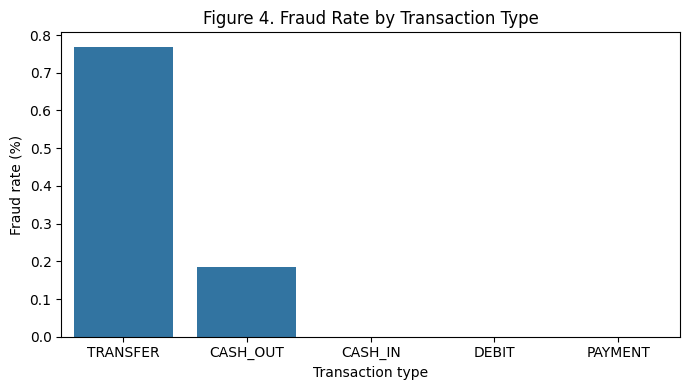

Saved: fraud_detection_outputs\figure_5_amount_distribution_by_fraud_class.png


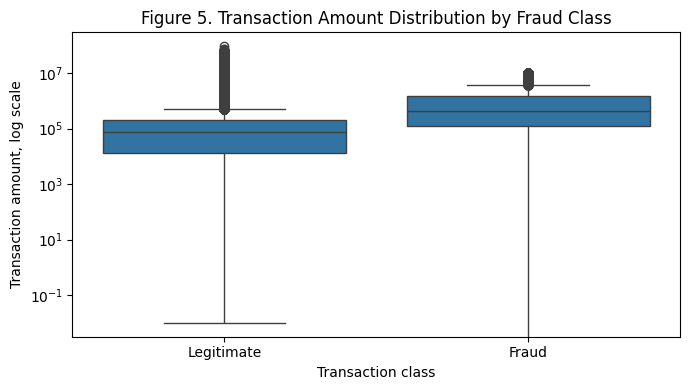

EDA figures saved in: fraud_detection_outputs


In [3]:
# I create the first EDA figures for the report

import os

output_dir = "fraud_detection_outputs"
os.makedirs(output_dir, exist_ok=True)

def save_chart(filename):
    path = os.path.join(output_dir, filename)
    plt.tight_layout()
    plt.savefig(path, dpi=300, bbox_inches="tight")
    print(f"Saved: {path}")

# Figure 1: Target class distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="isFraud")
plt.title("Figure 1. Distribution of Legitimate and Fraudulent Transactions")
plt.xlabel("Transaction class")
plt.ylabel("Number of transactions")
plt.xticks([0, 1], ["Legitimate", "Fraud"])
save_chart("figure_1_target_class_distribution.png")
plt.show()

# Figure 2: Transaction type distribution
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x="type", order=df["type"].value_counts().index)
plt.title("Figure 2. Distribution of Transaction Types")
plt.xlabel("Transaction type")
plt.ylabel("Number of transactions")
save_chart("figure_2_transaction_type_distribution.png")
plt.show()

# Figure 3: Fraud count by transaction type
fraud_type_counts = df[df["isFraud"] == 1]["type"].value_counts()

plt.figure(figsize=(7, 4))
sns.barplot(x=fraud_type_counts.index, y=fraud_type_counts.values)
plt.title("Figure 3. Fraudulent Transactions by Transaction Type")
plt.xlabel("Transaction type")
plt.ylabel("Number of fraudulent transactions")
save_chart("figure_3_fraud_by_transaction_type.png")
plt.show()

# Figure 4: Fraud rate by transaction type
fraud_rate_by_type = (
    df.groupby("type")["isFraud"]
    .mean()
    .sort_values(ascending=False) * 100
)

plt.figure(figsize=(7, 4))
sns.barplot(x=fraud_rate_by_type.index, y=fraud_rate_by_type.values)
plt.title("Figure 4. Fraud Rate by Transaction Type")
plt.xlabel("Transaction type")
plt.ylabel("Fraud rate (%)")
save_chart("figure_4_fraud_rate_by_transaction_type.png")
plt.show()

# Figure 5: Amount distribution by fraud class
# I use log scale because transaction amounts are highly skewed
plt.figure(figsize=(7, 4))
sns.boxplot(data=df, x="isFraud", y="amount")
plt.yscale("log")
plt.title("Figure 5. Transaction Amount Distribution by Fraud Class")
plt.xlabel("Transaction class")
plt.ylabel("Transaction amount, log scale")
plt.xticks([0, 1], ["Legitimate", "Fraud"])
save_chart("figure_5_amount_distribution_by_fraud_class.png")
plt.show()

print("EDA figures saved in:", output_dir)

In [4]:
# I create fraud-relevant engineered features from transaction balance logic

# I make a working copy so the original dataset stays unchanged
data = df.copy()

# Balance error features
# These measure whether the recorded old/new balances match the transaction amount
data["orig_balance_error"] = data["oldbalanceOrg"] - data["amount"] - data["newbalanceOrig"]
data["dest_balance_error"] = data["oldbalanceDest"] + data["amount"] - data["newbalanceDest"]

# Binary indicators based on transaction behaviour
data["orig_zero_after_transaction"] = (data["newbalanceOrig"] == 0).astype(int)
data["dest_zero_before_transaction"] = (data["oldbalanceDest"] == 0).astype(int)

# Amount-to-balance ratios
# I add 1 to avoid division by zero
data["amount_to_oldbalanceOrg"] = data["amount"] / (data["oldbalanceOrg"] + 1)
data["amount_to_oldbalanceDest"] = data["amount"] / (data["oldbalanceDest"] + 1)

# High-value transaction flag based on the 95th percentile
amount_95 = data["amount"].quantile(0.95)
data["high_value_transaction"] = (data["amount"] > amount_95).astype(int)

print("New engineered features added.")
print("95th percentile of transaction amount:", round(amount_95, 2))

engineered_features = [
    "orig_balance_error",
    "dest_balance_error",
    "orig_zero_after_transaction",
    "dest_zero_before_transaction",
    "amount_to_oldbalanceOrg",
    "amount_to_oldbalanceDest",
    "high_value_transaction"
]

print("\nEngineered features:")
print(engineered_features)

print("\nPreview of selected original and engineered features:")
display(data[
    [
        "type", "amount", "oldbalanceOrg", "newbalanceOrig",
        "oldbalanceDest", "newbalanceDest", "isFraud"
    ] + engineered_features
].head(10))

print("\nDescriptive statistics for numerical variables:")
numeric_cols = [
    "step", "amount", "oldbalanceOrg", "newbalanceOrig",
    "oldbalanceDest", "newbalanceDest"
] + engineered_features

display(data[numeric_cols].describe().T.round(3))

print("\nMean values by fraud class:")
class_means = data.groupby("isFraud")[numeric_cols].mean().T
class_means.columns = ["Legitimate mean", "Fraud mean"]
display(class_means.round(3))

New engineered features added.
95th percentile of transaction amount: 518634.2

Engineered features:
['orig_balance_error', 'dest_balance_error', 'orig_zero_after_transaction', 'dest_zero_before_transaction', 'amount_to_oldbalanceOrg', 'amount_to_oldbalanceDest', 'high_value_transaction']

Preview of selected original and engineered features:


,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,orig_balance_error,dest_balance_error,orig_zero_after_transaction,dest_zero_before_transaction,amount_to_oldbalanceOrg,amount_to_oldbalanceDest,high_value_transaction
0,PAYMENT,9839.64,170136.00,160296.36,0.0,0.00,0,0.000000e+00,9839.64,0,1,0.057834,9839.640000,0
1,PAYMENT,1864.28,21249.00,19384.72,0.0,0.00,0,0.000000e+00,1864.28,0,1,0.087731,1864.280000,0
2,TRANSFER,181.00,181.00,0.00,0.0,0.00,1,0.000000e+00,181.00,1,1,0.994505,181.000000,0
3,CASH_OUT,181.00,181.00,0.00,21182.0,0.00,1,0.000000e+00,21363.00,1,0,0.994505,0.008545,0
4,PAYMENT,11668.14,41554.00,29885.86,0.0,0.00,0,0.000000e+00,11668.14,0,1,0.280788,11668.140000,0
5,PAYMENT,7817.71,53860.00,46042.29,0.0,0.00,0,0.000000e+00,7817.71,0,1,0.145146,7817.710000,0
6,PAYMENT,7107.77,183195.00,176087.23,0.0,0.00,0,0.000000e+00,7107.77,0,1,0.038799,7107.770000,0
7,PAYMENT,7861.64,176087.23,168225.59,0.0,0.00,0,0.000000e+00,7861.64,0,1,0.044646,7861.640000,0
8,PAYMENT,4024.36,2671.00,0.00,0.0,0.00,0,-1.353360e+03,4024.36,1,1,1.506123,4024.360000,0
9,DEBIT,5337.77,41720.00,36382.23,41898.0,40348.79,0,-7.275958e-12,6886.98,0,0,0.127940,0.127396,0



Descriptive statistics for numerical variables:


,count,mean,std,min,25%,50%,75%,max
step,6362620.0,243.397,142.332,1.00,156.000,239.000,335.000,7.430000e+02
amount,6362620.0,179861.904,603858.231,0.00,13389.570,74871.940,208721.478,9.244552e+07
oldbalanceOrg,6362620.0,833883.104,2888242.673,0.00,0.000,14208.000,107315.175,5.958504e+07
newbalanceOrig,6362620.0,855113.669,2924048.503,0.00,0.000,0.000,144258.410,4.958504e+07
oldbalanceDest,6362620.0,1100701.667,3399180.113,0.00,0.000,132705.665,943036.708,3.560159e+08
newbalanceDest,6362620.0,1224996.398,3674128.942,0.00,0.000,214661.440,1111909.250,3.561793e+08
orig_balance_error,6362620.0,-201092.468,606650.460,-92445516.64,-249641.088,-68677.255,-2954.230,1.000000e-02
dest_balance_error,6362620.0,55567.172,441528.769,-75885725.63,0.000,3500.490,29353.045,1.319123e+07
orig_zero_after_transaction,6362620.0,0.567,0.495,0.00,0.000,1.000,1.000,1.000000e+00
dest_zero_before_transaction,6362620.0,0.425,0.494,0.00,0.000,0.000,1.000,1.000000e+00



Mean values by fraud class:


,Legitimate mean,Fraud mean
step,243.236,368.414
amount,178197.042,1467967.299
oldbalanceOrg,832828.712,1649667.606
newbalanceOrig,855970.228,192392.632
oldbalanceDest,1101420.875,544249.619
newbalanceDest,1224925.685,1279707.617
orig_balance_error,-201338.558,-10692.325
dest_balance_error,54692.232,732509.301
orig_zero_after_transaction,0.567,0.981
dest_zero_before_transaction,0.425,0.652


Correlation with fraud target:


,Correlation with isFraud
isFraud,1.0000
amount_to_oldbalanceDest,0.1802
amount,0.0767
high_value_transaction,0.0681
dest_balance_error,0.0551
isFlaggedFraud,0.0441
step,0.0316
orig_zero_after_transaction,0.0300
dest_zero_before_transaction,0.0165
orig_balance_error,0.0113


Saved: fraud_detection_outputs\figure_6_correlation_heatmap.png


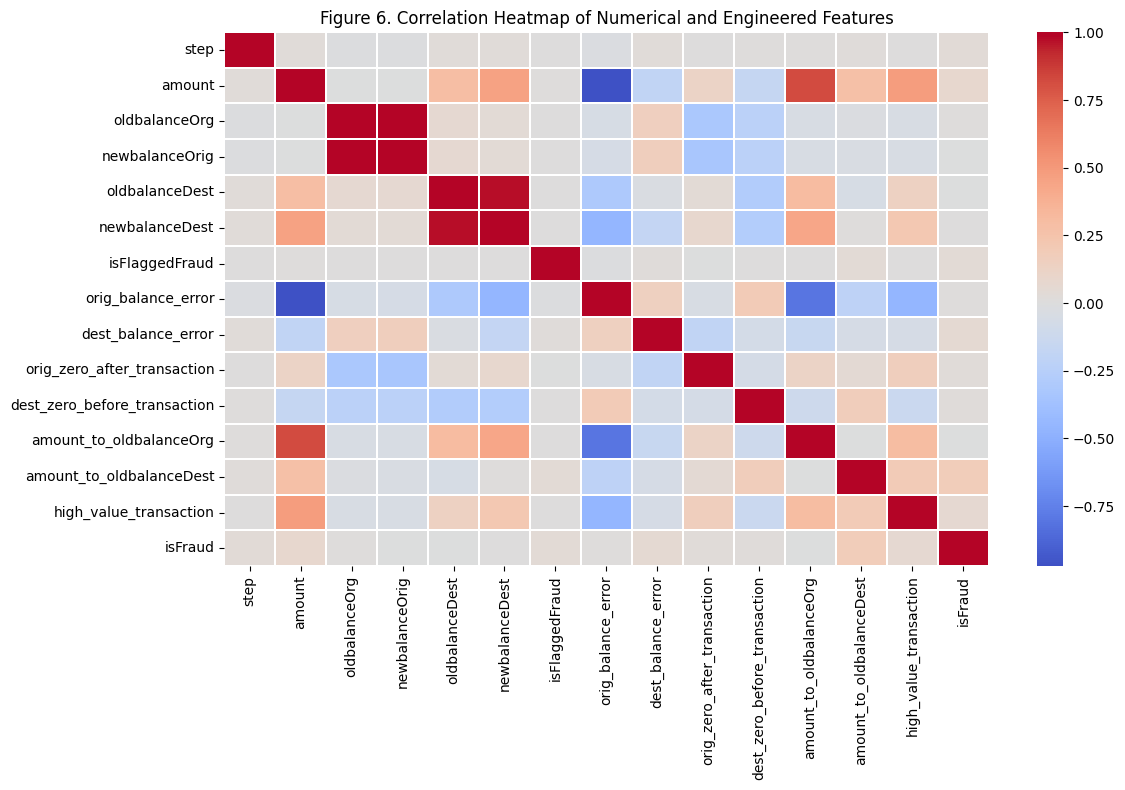

Saved: fraud_detection_outputs\figure_7_mean_amount_by_fraud_class.png


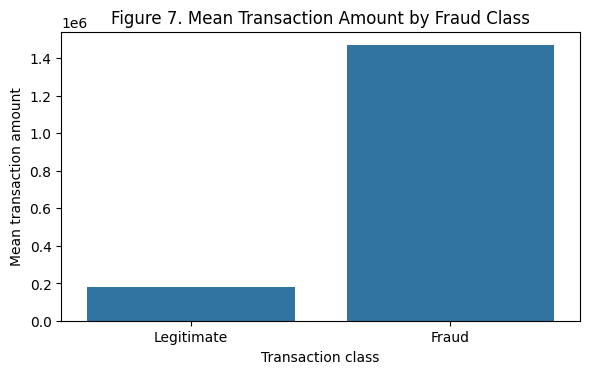

Saved: fraud_detection_outputs\figure_8_sender_zero_after_transaction.png


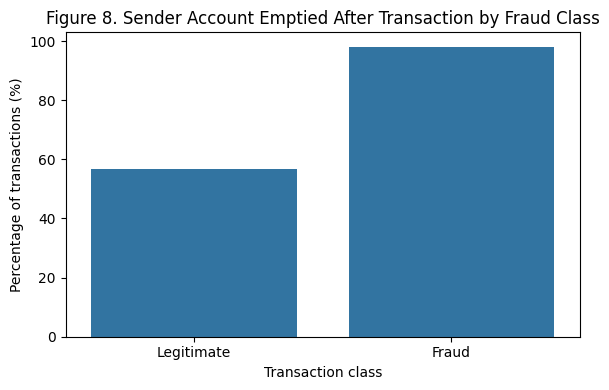

Saved: fraud_detection_outputs\figure_9_high_value_transaction_rate.png


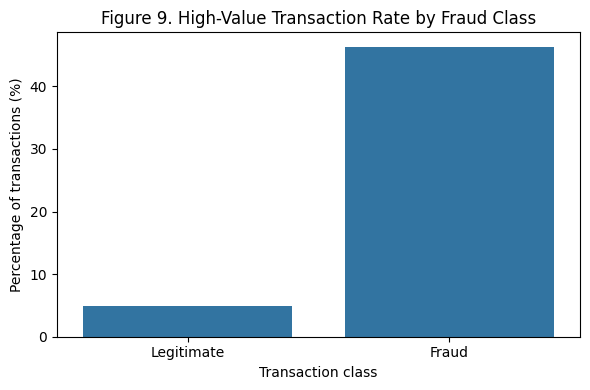

Saved: fraud_detection_outputs\figure_10_fraud_across_time_steps.png


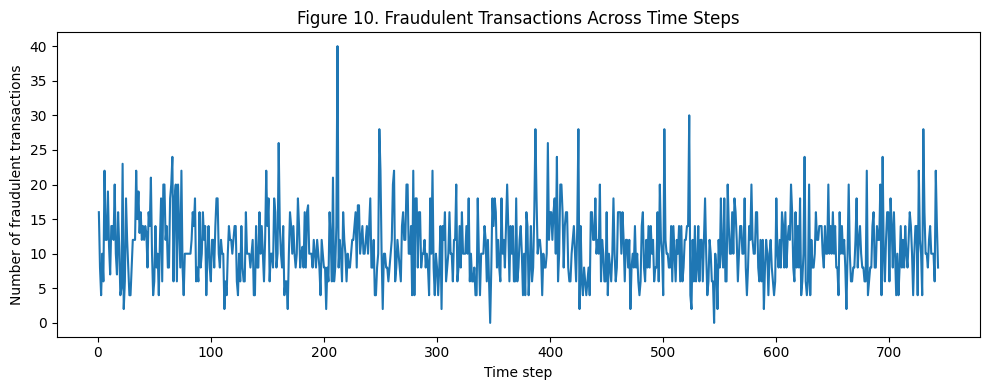

In [5]:
# I examine correlations and create stronger EDA figures

# Correlation table with the target
corr_cols = [
    "step", "amount", "oldbalanceOrg", "newbalanceOrig",
    "oldbalanceDest", "newbalanceDest", "isFlaggedFraud",
    "orig_balance_error", "dest_balance_error",
    "orig_zero_after_transaction", "dest_zero_before_transaction",
    "amount_to_oldbalanceOrg", "amount_to_oldbalanceDest",
    "high_value_transaction", "isFraud"
]

corr_with_target = (
    data[corr_cols]
    .corr(numeric_only=True)["isFraud"]
    .sort_values(ascending=False)
    .to_frame(name="Correlation with isFraud")
)

print("Correlation with fraud target:")
display(corr_with_target.round(4))

# Figure 6: Correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(
    data[corr_cols].corr(numeric_only=True),
    cmap="coolwarm",
    center=0,
    linewidths=0.3
)
plt.title("Figure 6. Correlation Heatmap of Numerical and Engineered Features")
save_chart("figure_6_correlation_heatmap.png")
plt.show()

# Figure 7: Mean transaction amount by fraud class
amount_means = data.groupby("isFraud")["amount"].mean()

plt.figure(figsize=(6, 4))
sns.barplot(x=amount_means.index, y=amount_means.values)
plt.title("Figure 7. Mean Transaction Amount by Fraud Class")
plt.xlabel("Transaction class")
plt.ylabel("Mean transaction amount")
plt.xticks([0, 1], ["Legitimate", "Fraud"])
save_chart("figure_7_mean_amount_by_fraud_class.png")
plt.show()

# Figure 8: Sender account emptied after transaction
empty_sender_rate = data.groupby("isFraud")["orig_zero_after_transaction"].mean() * 100

plt.figure(figsize=(6, 4))
sns.barplot(x=empty_sender_rate.index, y=empty_sender_rate.values)
plt.title("Figure 8. Sender Account Emptied After Transaction by Fraud Class")
plt.xlabel("Transaction class")
plt.ylabel("Percentage of transactions (%)")
plt.xticks([0, 1], ["Legitimate", "Fraud"])
save_chart("figure_8_sender_zero_after_transaction.png")
plt.show()

# Figure 9: High-value transaction rate by fraud class
high_value_rate = data.groupby("isFraud")["high_value_transaction"].mean() * 100

plt.figure(figsize=(6, 4))
sns.barplot(x=high_value_rate.index, y=high_value_rate.values)
plt.title("Figure 9. High-Value Transaction Rate by Fraud Class")
plt.xlabel("Transaction class")
plt.ylabel("Percentage of transactions (%)")
plt.xticks([0, 1], ["Legitimate", "Fraud"])
save_chart("figure_9_high_value_transaction_rate.png")
plt.show()

# Figure 10: Fraud trend across time steps
fraud_by_step = data.groupby("step")["isFraud"].sum()

plt.figure(figsize=(10, 4))
plt.plot(fraud_by_step.index, fraud_by_step.values)
plt.title("Figure 10. Fraudulent Transactions Across Time Steps")
plt.xlabel("Time step")
plt.ylabel("Number of fraudulent transactions")
save_chart("figure_10_fraud_across_time_steps.png")
plt.show()

In [6]:
# I prepare the modelling dataset in a memory-safe way

from sklearn.model_selection import train_test_split

# I remove account identifiers because they are high-cardinality IDs, not useful behavioural predictors
drop_columns = ["nameOrig", "nameDest"]

model_data = data.drop(columns=drop_columns).copy()

print("Columns available for modelling:")
print(model_data.columns.tolist())

print("\nFull dataset fraud distribution:")
display(model_data["isFraud"].value_counts())

# Keep all fraud cases and sample legitimate cases for efficient modelling
fraud_cases = model_data[model_data["isFraud"] == 1]
legit_cases = model_data[model_data["isFraud"] == 0]

# I use a controlled legitimate sample to reduce training time while keeping all fraud examples
legit_sample = legit_cases.sample(n=300000, random_state=42)

model_sample = pd.concat([fraud_cases, legit_sample], axis=0)
model_sample = model_sample.sample(frac=1, random_state=42).reset_index(drop=True)

print("\nModelling sample shape:", model_sample.shape)

print("\nModelling sample target distribution:")
sample_dist = pd.DataFrame({
    "Count": model_sample["isFraud"].value_counts().sort_index(),
    "Percentage": (model_sample["isFraud"].value_counts(normalize=True).sort_index() * 100).round(3)
})
sample_dist.index = ["Legitimate", "Fraud"]
display(sample_dist)

# Separate features and target
X = model_sample.drop(columns=["isFraud"])
y = model_sample["isFraud"]

# One-hot encode transaction type
X = pd.get_dummies(X, columns=["type"], drop_first=True)

print("\nFeature columns after encoding:")
print(X.columns.tolist())

print("\nFeature matrix shape:", X.shape)

# Stratified train-test split keeps the fraud proportion consistent
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

print("\nTraining target distribution:")
display(y_train.value_counts(normalize=True).mul(100).round(3).to_frame("Percentage"))

print("\nTest target distribution:")
display(y_test.value_counts(normalize=True).mul(100).round(3).to_frame("Percentage"))

Columns available for modelling:
['step', 'type', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud', 'orig_balance_error', 'dest_balance_error', 'orig_zero_after_transaction', 'dest_zero_before_transaction', 'amount_to_oldbalanceOrg', 'amount_to_oldbalanceDest', 'high_value_transaction']

Full dataset fraud distribution:


isFraud
0    6354407
1       8213
Name: count, dtype: int64


Modelling sample shape: (308213, 16)

Modelling sample target distribution:


,Count,Percentage
Legitimate,300000,97.335
Fraud,8213,2.665



Feature columns after encoding:
['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'isFlaggedFraud', 'orig_balance_error', 'dest_balance_error', 'orig_zero_after_transaction', 'dest_zero_before_transaction', 'amount_to_oldbalanceOrg', 'amount_to_oldbalanceDest', 'high_value_transaction', 'type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER']

Feature matrix shape: (308213, 18)

Training set shape: (246570, 18)
Test set shape: (61643, 18)

Training target distribution:


,Percentage
isFraud,
0,97.335
1,2.665



Test target distribution:


,Percentage
isFraud,
0,97.335
1,2.665


In [7]:
# I train a Logistic Regression baseline model

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)

# Function to evaluate models consistently
def evaluate_model(model_name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    else:
        y_score = y_pred

    results = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1-score": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_score)
    }
    
    print(f"\n{model_name} performance:")
    for key, value in results.items():
        if key != "Model":
            print(f"{key}: {value:.4f}")
    
    print("\nConfusion matrix:")
    cm = confusion_matrix(y_test, y_pred)
    display(pd.DataFrame(
        cm,
        index=["Actual Legitimate", "Actual Fraud"],
        columns=["Predicted Legitimate", "Predicted Fraud"]
    ))
    
    print("\nClassification report:")
    print(classification_report(y_test, y_pred, target_names=["Legitimate", "Fraud"]))
    
    return results, cm

# Logistic Regression pipeline
logistic_model = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

logistic_model.fit(X_train, y_train)

logistic_results, logistic_cm = evaluate_model(
    "Logistic Regression",
    logistic_model,
    X_test,
    y_test
)


Logistic Regression performance:
Accuracy: 0.9819
Precision: 0.5958
Recall: 0.9951
F1-score: 0.7454
ROC-AUC: 0.9987

Confusion matrix:


,Predicted Legitimate,Predicted Fraud
Actual Legitimate,58891,1109
Actual Fraud,8,1635



Classification report:
              precision    recall  f1-score   support

  Legitimate       1.00      0.98      0.99     60000
       Fraud       0.60      1.00      0.75      1643

    accuracy                           0.98     61643
   macro avg       0.80      0.99      0.87     61643
weighted avg       0.99      0.98      0.98     61643



In [8]:
# I train tree-based models for stronger non-linear fraud detection

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Decision Tree model
decision_tree = DecisionTreeClassifier(
    max_depth=12,
    min_samples_split=50,
    min_samples_leaf=20,
    class_weight="balanced",
    random_state=42
)

decision_tree.fit(X_train, y_train)

tree_results, tree_cm = evaluate_model(
    "Decision Tree",
    decision_tree,
    X_test,
    y_test
)

# Random Forest model
random_forest = RandomForestClassifier(
    n_estimators=150,
    max_depth=16,
    min_samples_split=50,
    min_samples_leaf=20,
    class_weight="balanced_subsample",
    random_state=42,
    n_jobs=-1
)

random_forest.fit(X_train, y_train)

forest_results, forest_cm = evaluate_model(
    "Random Forest",
    random_forest,
    X_test,
    y_test
)


Decision Tree performance:
Accuracy: 0.9984
Precision: 0.9426
Recall: 0.9994
F1-score: 0.9702
ROC-AUC: 0.9997

Confusion matrix:


,Predicted Legitimate,Predicted Fraud
Actual Legitimate,59900,100
Actual Fraud,1,1642



Classification report:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     60000
       Fraud       0.94      1.00      0.97      1643

    accuracy                           1.00     61643
   macro avg       0.97      1.00      0.98     61643
weighted avg       1.00      1.00      1.00     61643


Random Forest performance:
Accuracy: 0.9999
Precision: 0.9964
Recall: 0.9988
F1-score: 0.9976
ROC-AUC: 1.0000

Confusion matrix:


,Predicted Legitimate,Predicted Fraud
Actual Legitimate,59994,6
Actual Fraud,2,1641



Classification report:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     60000
       Fraud       1.00      1.00      1.00      1643

    accuracy                           1.00     61643
   macro avg       1.00      1.00      1.00     61643
weighted avg       1.00      1.00      1.00     61643



In [9]:
# I train a Gradient Boosting model for comparison with tree ensembles

from sklearn.ensemble import HistGradientBoostingClassifier

gradient_boosting = HistGradientBoostingClassifier(
    max_iter=150,
    learning_rate=0.08,
    max_leaf_nodes=31,
    l2_regularization=0.1,
    random_state=42
)

gradient_boosting.fit(X_train, y_train)

gb_results, gb_cm = evaluate_model(
    "Gradient Boosting",
    gradient_boosting,
    X_test,
    y_test
)


Gradient Boosting performance:
Accuracy: 0.9999
Precision: 0.9982
Recall: 0.9988
F1-score: 0.9985
ROC-AUC: 0.9999

Confusion matrix:


,Predicted Legitimate,Predicted Fraud
Actual Legitimate,59997,3
Actual Fraud,2,1641



Classification report:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     60000
       Fraud       1.00      1.00      1.00      1643

    accuracy                           1.00     61643
   macro avg       1.00      1.00      1.00     61643
weighted avg       1.00      1.00      1.00     61643



Final model comparison:


,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Gradient Boosting,0.9999,0.9982,0.9988,0.9985,0.9999
1,Random Forest,0.9999,0.9964,0.9988,0.9976,1.0000
2,Decision Tree,0.9984,0.9426,0.9994,0.9702,0.9997
3,Logistic Regression,0.9819,0.5958,0.9951,0.7454,0.9987


Saved model comparison table to: fraud_detection_outputs\table_model_comparison.csv
Saved: fraud_detection_outputs\figure_11_model_performance_comparison.png


<Figure size 900x500 with 0 Axes>

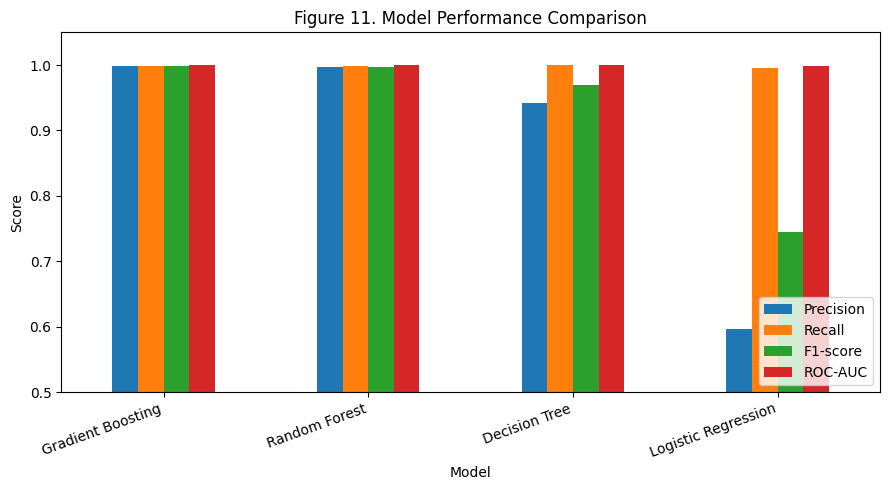

In [10]:
# I compare all trained models in one clean table

model_results = [
    logistic_results,
    tree_results,
    forest_results,
    gb_results
]

comparison_df = pd.DataFrame(model_results)

metric_cols = ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]
comparison_df[metric_cols] = comparison_df[metric_cols].round(4)

comparison_df = comparison_df.sort_values(
    by=["F1-score", "Recall", "Precision"],
    ascending=False
).reset_index(drop=True)

print("Final model comparison:")
display(comparison_df)

# Save comparison table
comparison_path = os.path.join(output_dir, "table_model_comparison.csv")
comparison_df.to_csv(comparison_path, index=False)

print(f"Saved model comparison table to: {comparison_path}")

# Figure 11: Model performance comparison
comparison_plot = comparison_df.set_index("Model")[["Precision", "Recall", "F1-score", "ROC-AUC"]]

plt.figure(figsize=(9, 5))
comparison_plot.plot(kind="bar", figsize=(9, 5))
plt.title("Figure 11. Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0.5, 1.05)
plt.xticks(rotation=20, ha="right")
plt.legend(loc="lower right")
save_chart("figure_11_model_performance_comparison.png")
plt.show()

Saved: fraud_detection_outputs\figure_12_logistic_regression_confusion_matrix.png


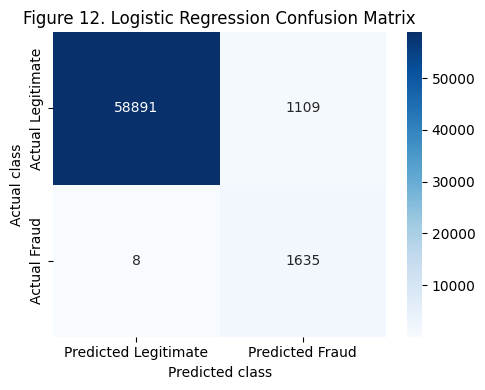

Saved: fraud_detection_outputs\figure_13_decision_tree_confusion_matrix.png


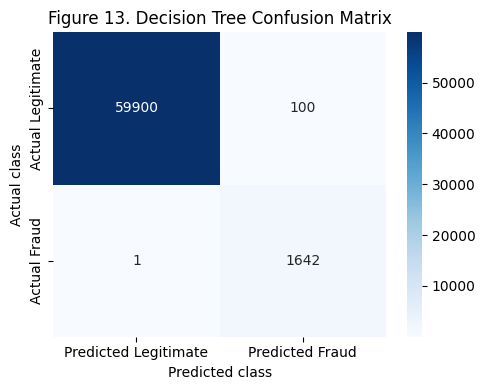

Saved: fraud_detection_outputs\figure_14_random_forest_confusion_matrix.png


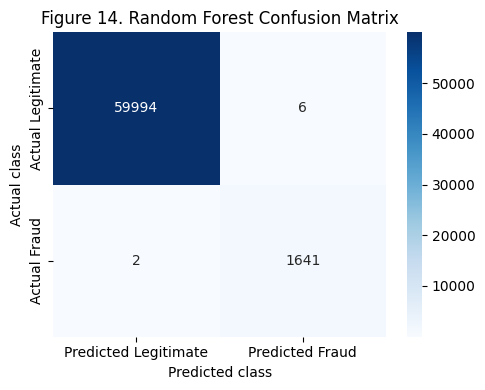

Saved: fraud_detection_outputs\figure_15_gradient_boosting_confusion_matrix.png


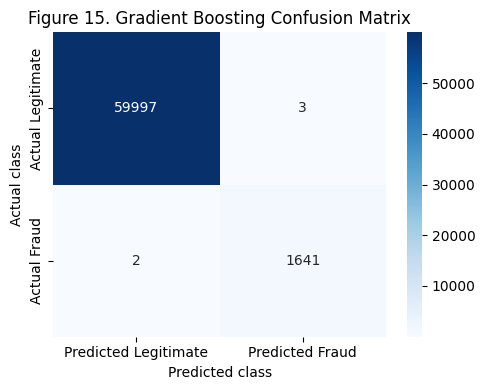

In [11]:
# I save confusion matrix figures for each model

def plot_confusion_matrix(cm, model_name, filename):
    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Predicted Legitimate", "Predicted Fraud"],
        yticklabels=["Actual Legitimate", "Actual Fraud"]
    )
    plt.title(f"{model_name} Confusion Matrix")
    plt.xlabel("Predicted class")
    plt.ylabel("Actual class")
    save_chart(filename)
    plt.show()

plot_confusion_matrix(
    logistic_cm,
    "Figure 12. Logistic Regression",
    "figure_12_logistic_regression_confusion_matrix.png"
)

plot_confusion_matrix(
    tree_cm,
    "Figure 13. Decision Tree",
    "figure_13_decision_tree_confusion_matrix.png"
)

plot_confusion_matrix(
    forest_cm,
    "Figure 14. Random Forest",
    "figure_14_random_forest_confusion_matrix.png"
)

plot_confusion_matrix(
    gb_cm,
    "Figure 15. Gradient Boosting",
    "figure_15_gradient_boosting_confusion_matrix.png"
)

Permutation importance sample shape: (10000, 18)
Fraud cases in importance sample: 283
Top feature importance values:


,Feature,Importance_Mean,Importance_Std
7,orig_balance_error,0.85329,0.00444
3,newbalanceOrig,0.74871,0.00723
12,amount_to_oldbalanceDest,0.01132,0.00262
1,amount,0.01028,0.00132
11,amount_to_oldbalanceOrg,0.00424,0.00287
8,dest_balance_error,0.00142,0.00071
0,step,0.00035,0.00071
2,oldbalanceOrg,0.00035,0.00071
5,newbalanceDest,0.00000,0.00000
4,oldbalanceDest,0.00000,0.00000


Saved feature importance table to: fraud_detection_outputs\table_gradient_boosting_permutation_importance.csv
Saved: fraud_detection_outputs\figure_16_gradient_boosting_feature_importance.png


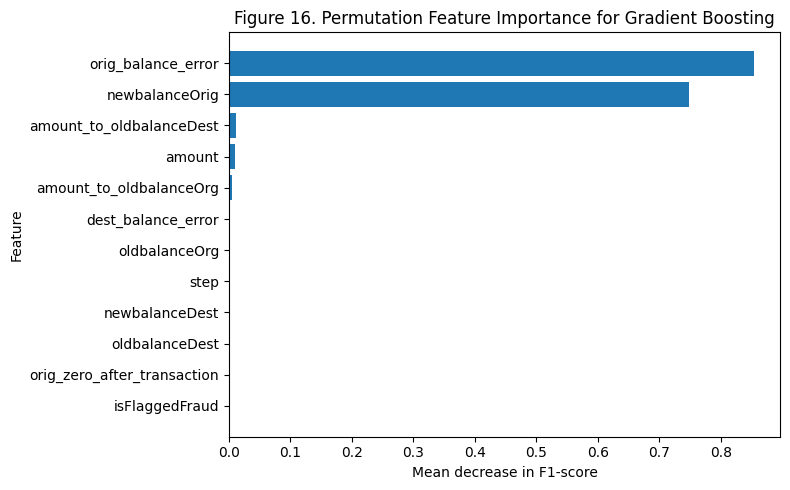

In [12]:
# I calculate permutation importance for the final Gradient Boosting model

from sklearn.inspection import permutation_importance

# I use a smaller test subset so permutation importance runs safely
importance_sample_size = min(10000, X_test.shape[0])

X_importance = X_test.sample(n=importance_sample_size, random_state=42)
y_importance = y_test.loc[X_importance.index]

print("Permutation importance sample shape:", X_importance.shape)
print("Fraud cases in importance sample:", int(y_importance.sum()))

perm_importance = permutation_importance(
    gradient_boosting,
    X_importance,
    y_importance,
    n_repeats=5,
    random_state=42,
    scoring="f1",
    n_jobs=-1
)

importance_df = pd.DataFrame({
    "Feature": X_importance.columns,
    "Importance_Mean": perm_importance.importances_mean,
    "Importance_Std": perm_importance.importances_std
}).sort_values(by="Importance_Mean", ascending=False)

print("Top feature importance values:")
display(importance_df.head(15).round(5))

# Save feature importance table
importance_path = os.path.join(output_dir, "table_gradient_boosting_permutation_importance.csv")
importance_df.to_csv(importance_path, index=False)
print(f"Saved feature importance table to: {importance_path}")

# Figure 16: Top 12 feature importance
top_features = importance_df.head(12).sort_values(by="Importance_Mean", ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(top_features["Feature"], top_features["Importance_Mean"])
plt.title("Figure 16. Permutation Feature Importance for Gradient Boosting")
plt.xlabel("Mean decrease in F1-score")
plt.ylabel("Feature")
save_chart("figure_16_gradient_boosting_feature_importance.png")
plt.show()

Saved: fraud_detection_outputs\figure_17_roc_curve_comparison.png


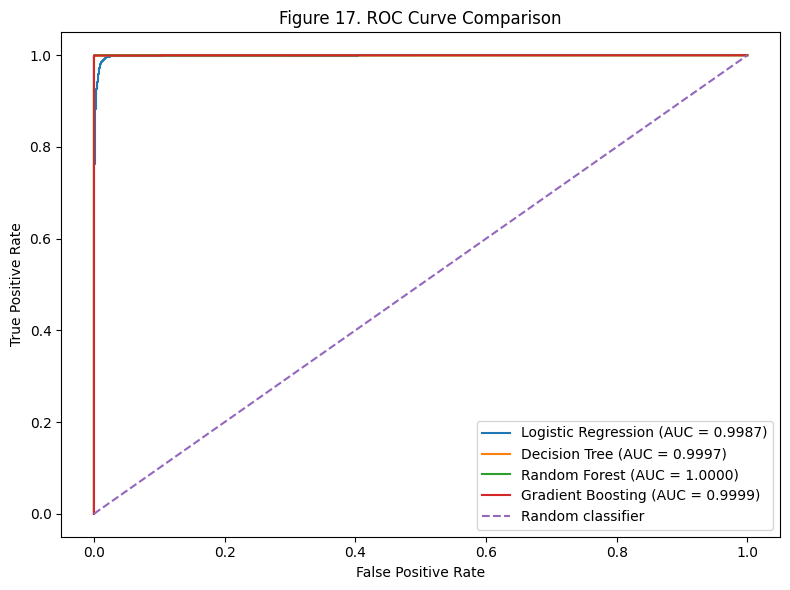

ROC-AUC summary:


,Model,ROC-AUC
2,Random Forest,1.0000
3,Gradient Boosting,0.9999
1,Decision Tree,0.9997
0,Logistic Regression,0.9987


Saved: fraud_detection_outputs\figure_18_precision_recall_curve_comparison.png


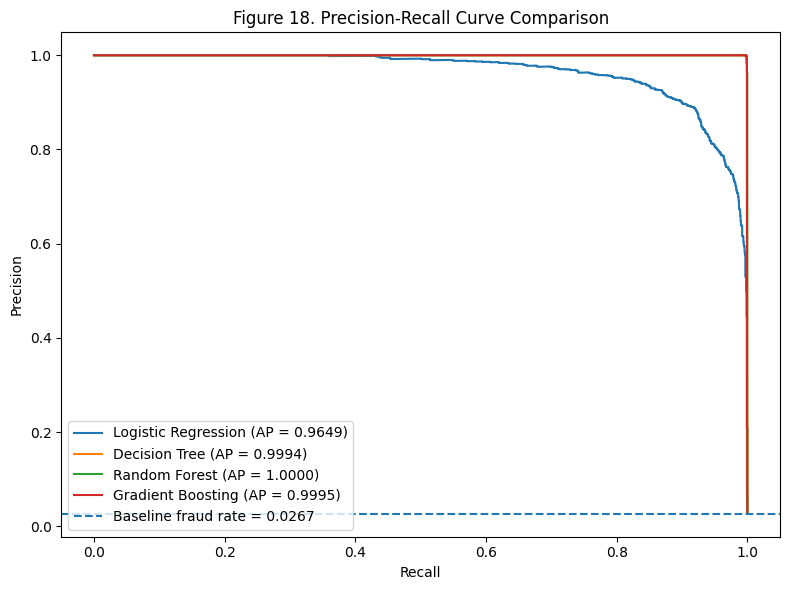

Precision-Recall summary:


,Model,PR-AUC,Average Precision
2,Random Forest,1.0000,1.0000
3,Gradient Boosting,0.9995,0.9995
1,Decision Tree,0.9997,0.9994
0,Logistic Regression,0.9649,0.9649


In [13]:
# I create ROC and Precision-Recall curves for model comparison

from sklearn.metrics import roc_curve, precision_recall_curve, auc, average_precision_score

models_for_curves = {
    "Logistic Regression": logistic_model,
    "Decision Tree": decision_tree,
    "Random Forest": random_forest,
    "Gradient Boosting": gradient_boosting
}

# Figure 17: ROC Curves
plt.figure(figsize=(8, 6))

roc_summary = []

for model_name, model in models_for_curves.items():
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    else:
        y_score = model.predict(X_test)
    
    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc_value = auc(fpr, tpr)
    
    roc_summary.append({
        "Model": model_name,
        "ROC-AUC": roc_auc_value
    })
    
    plt.plot(fpr, tpr, label=f"{model_name} (AUC = {roc_auc_value:.4f})")

plt.plot([0, 1], [0, 1], linestyle="--", label="Random classifier")
plt.title("Figure 17. ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
save_chart("figure_17_roc_curve_comparison.png")
plt.show()

roc_summary_df = pd.DataFrame(roc_summary).sort_values(by="ROC-AUC", ascending=False)
print("ROC-AUC summary:")
display(roc_summary_df.round(4))


# Figure 18: Precision-Recall Curves
plt.figure(figsize=(8, 6))

pr_summary = []

for model_name, model in models_for_curves.items():
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    else:
        y_score = model.predict(X_test)
    
    precision, recall, _ = precision_recall_curve(y_test, y_score)
    pr_auc_value = auc(recall, precision)
    avg_precision = average_precision_score(y_test, y_score)
    
    pr_summary.append({
        "Model": model_name,
        "PR-AUC": pr_auc_value,
        "Average Precision": avg_precision
    })
    
    plt.plot(recall, precision, label=f"{model_name} (AP = {avg_precision:.4f})")

baseline_precision = y_test.mean()
plt.axhline(y=baseline_precision, linestyle="--", label=f"Baseline fraud rate = {baseline_precision:.4f}")

plt.title("Figure 18. Precision-Recall Curve Comparison")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend(loc="lower left")
save_chart("figure_18_precision_recall_curve_comparison.png")
plt.show()

pr_summary_df = pd.DataFrame(pr_summary).sort_values(by="Average Precision", ascending=False)
print("Precision-Recall summary:")
display(pr_summary_df.round(4))

# Save curve summaries
roc_summary_df.to_csv(os.path.join(output_dir, "table_roc_auc_summary.csv"), index=False)
pr_summary_df.to_csv(os.path.join(output_dir, "table_precision_recall_summary.csv"), index=False)

Threshold analysis for Gradient Boosting:


,Threshold,Precision,Recall,F1-score,False Positives,False Negatives,True Frauds Detected
0,0.05,0.9939,0.9988,0.9964,10,2,1641
1,0.10,0.9945,0.9988,0.9967,9,2,1641
2,0.15,0.9945,0.9988,0.9967,9,2,1641
3,0.20,0.9951,0.9988,0.9970,8,2,1641
4,0.25,0.9951,0.9988,0.9970,8,2,1641
5,0.30,0.9958,0.9988,0.9973,7,2,1641
6,0.35,0.9976,0.9988,0.9982,4,2,1641
7,0.40,0.9976,0.9988,0.9982,4,2,1641
8,0.45,0.9982,0.9988,0.9985,3,2,1641
9,0.50,0.9982,0.9988,0.9985,3,2,1641



Best threshold by F1-score:


,Threshold,Precision,Recall,F1-score,False Positives,False Negatives,True Frauds Detected
18,0.95,1.0,0.9988,0.9994,0.0,2.0,1641.0


Saved threshold analysis table to: fraud_detection_outputs\table_gradient_boosting_threshold_analysis.csv
Saved: fraud_detection_outputs\figure_19_gradient_boosting_threshold_analysis.png


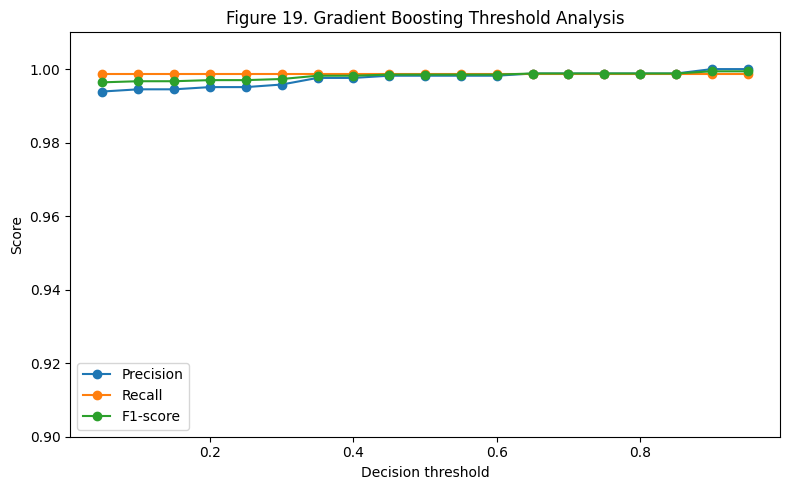

In [14]:
# I test different probability thresholds for the final Gradient Boosting model

from sklearn.metrics import precision_recall_fscore_support

# Predicted fraud probabilities from the final model
gb_proba = gradient_boosting.predict_proba(X_test)[:, 1]

thresholds = np.arange(0.05, 0.96, 0.05)

threshold_results = []

for threshold in thresholds:
    y_pred_threshold = (gb_proba >= threshold).astype(int)
    
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test,
        y_pred_threshold,
        average="binary",
        zero_division=0
    )
    
    cm = confusion_matrix(y_test, y_pred_threshold)
    tn, fp, fn, tp = cm.ravel()
    
    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1,
        "False Positives": fp,
        "False Negatives": fn,
        "True Frauds Detected": tp
    })

threshold_df = pd.DataFrame(threshold_results)
threshold_df[["Precision", "Recall", "F1-score"]] = threshold_df[["Precision", "Recall", "F1-score"]].round(4)

print("Threshold analysis for Gradient Boosting:")
display(threshold_df)

# Best threshold by F1-score
best_threshold_row = threshold_df.sort_values(by="F1-score", ascending=False).iloc[0]

print("\nBest threshold by F1-score:")
display(best_threshold_row.to_frame().T)

# Save threshold table
threshold_path = os.path.join(output_dir, "table_gradient_boosting_threshold_analysis.csv")
threshold_df.to_csv(threshold_path, index=False)
print(f"Saved threshold analysis table to: {threshold_path}")

# Figure 19: Precision, Recall and F1-score across thresholds
plt.figure(figsize=(8, 5))
plt.plot(threshold_df["Threshold"], threshold_df["Precision"], marker="o", label="Precision")
plt.plot(threshold_df["Threshold"], threshold_df["Recall"], marker="o", label="Recall")
plt.plot(threshold_df["Threshold"], threshold_df["F1-score"], marker="o", label="F1-score")

plt.title("Figure 19. Gradient Boosting Threshold Analysis")
plt.xlabel("Decision threshold")
plt.ylabel("Score")
plt.ylim(0.90, 1.01)
plt.legend(loc="lower left")
save_chart("figure_19_gradient_boosting_threshold_analysis.png")
plt.show()

Final selected model performance:


,Model,Threshold,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Gradient Boosting - Optimised Threshold,0.95,1.0,1.0,0.9988,0.9994,0.9999



Final selected model confusion matrix:


,Predicted Legitimate,Predicted Fraud
Actual Legitimate,60000,0
Actual Fraud,2,1641



Final selected model classification report:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     60000
       Fraud       1.00      1.00      1.00      1643

    accuracy                           1.00     61643
   macro avg       1.00      1.00      1.00     61643
weighted avg       1.00      1.00      1.00     61643

Saved final selected model table to: fraud_detection_outputs\table_final_selected_model.csv
Saved: fraud_detection_outputs\figure_20_final_gradient_boosting_confusion_matrix.png


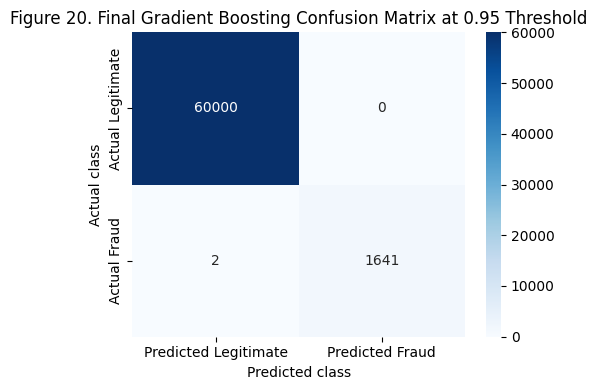

In [15]:
# I evaluate the final Gradient Boosting model using the selected threshold

final_threshold = 0.95

final_pred = (gb_proba >= final_threshold).astype(int)

final_accuracy = accuracy_score(y_test, final_pred)
final_precision = precision_score(y_test, final_pred, zero_division=0)
final_recall = recall_score(y_test, final_pred, zero_division=0)
final_f1 = f1_score(y_test, final_pred, zero_division=0)
final_roc_auc = roc_auc_score(y_test, gb_proba)

final_results = pd.DataFrame([{
    "Model": "Gradient Boosting - Optimised Threshold",
    "Threshold": final_threshold,
    "Accuracy": final_accuracy,
    "Precision": final_precision,
    "Recall": final_recall,
    "F1-score": final_f1,
    "ROC-AUC": final_roc_auc
}])

final_results[["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]] = (
    final_results[["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]].round(4)
)

print("Final selected model performance:")
display(final_results)

final_cm = confusion_matrix(y_test, final_pred)

print("\nFinal selected model confusion matrix:")
display(pd.DataFrame(
    final_cm,
    index=["Actual Legitimate", "Actual Fraud"],
    columns=["Predicted Legitimate", "Predicted Fraud"]
))

print("\nFinal selected model classification report:")
print(classification_report(y_test, final_pred, target_names=["Legitimate", "Fraud"]))

# Save final selected model performance table
final_results_path = os.path.join(output_dir, "table_final_selected_model.csv")
final_results.to_csv(final_results_path, index=False)
print(f"Saved final selected model table to: {final_results_path}")

# Figure 20: Final selected model confusion matrix
plt.figure(figsize=(5, 4))
sns.heatmap(
    final_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted Legitimate", "Predicted Fraud"],
    yticklabels=["Actual Legitimate", "Actual Fraud"]
)
plt.title("Figure 20. Final Gradient Boosting Confusion Matrix at 0.95 Threshold")
plt.xlabel("Predicted class")
plt.ylabel("Actual class")
save_chart("figure_20_final_gradient_boosting_confusion_matrix.png")
plt.show()

In [17]:
# I test the final model on unused legitimate transactions

# These legitimate transactions were not included in the modelling sample
unused_legit = legit_cases.drop(index=legit_sample.index)

print("Unused legitimate transactions available:", unused_legit.shape[0])
print("Columns in unused_legit:")
print(unused_legit.columns.tolist())

# I use a large validation sample to test false positives realistically
unused_validation_size = min(500000, unused_legit.shape[0])

unused_legit_validation = unused_legit.sample(
    n=unused_validation_size,
    random_state=42
).copy()

# Remove only the target column because identifiers were already removed earlier
X_unused = unused_legit_validation.drop(columns=["isFraud"])

# One-hot encode transaction type
X_unused = pd.get_dummies(X_unused, columns=["type"], drop_first=True)

# Align columns with the training feature matrix
X_unused = X_unused.reindex(columns=X_train.columns, fill_value=0)

# Predict with the final selected threshold
unused_proba = gradient_boosting.predict_proba(X_unused)[:, 1]
unused_pred = (unused_proba >= final_threshold).astype(int)

false_positives_unused = int(unused_pred.sum())
false_positive_rate_unused = false_positives_unused / unused_validation_size

print("\nUnused legitimate validation sample size:", unused_validation_size)
print("False positives on unused legitimate transactions:", false_positives_unused)
print("False positive rate:", round(false_positive_rate_unused, 8))
print("False positive percentage:", round(false_positive_rate_unused * 100, 6), "%")

unused_validation_summary = pd.DataFrame([{
    "Validation sample": "Unused legitimate transactions",
    "Sample size": unused_validation_size,
    "False positives": false_positives_unused,
    "False positive rate": false_positive_rate_unused,
    "False positive percentage": false_positive_rate_unused * 100
}])

display(unused_validation_summary)

# Save this validation result
unused_validation_path = os.path.join(output_dir, "table_unused_legitimate_validation.csv")
unused_validation_summary.to_csv(unused_validation_path, index=False)

print(f"Saved unused legitimate validation table to: {unused_validation_path}")

Unused legitimate transactions available: 6054407
Columns in unused_legit:
['step', 'type', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud', 'orig_balance_error', 'dest_balance_error', 'orig_zero_after_transaction', 'dest_zero_before_transaction', 'amount_to_oldbalanceOrg', 'amount_to_oldbalanceDest', 'high_value_transaction']

Unused legitimate validation sample size: 500000
False positives on unused legitimate transactions: 0
False positive rate: 0.0
False positive percentage: 0.0 %


,Validation sample,Sample size,False positives,False positive rate,False positive percentage
0,Unused legitimate transactions,500000,0,0.0,0.0


Saved unused legitimate validation table to: fraud_detection_outputs\table_unused_legitimate_validation.csv


Saved clean Figure 11 to: fraud_detection_outputs\figure_11_model_performance_comparison_clean.png


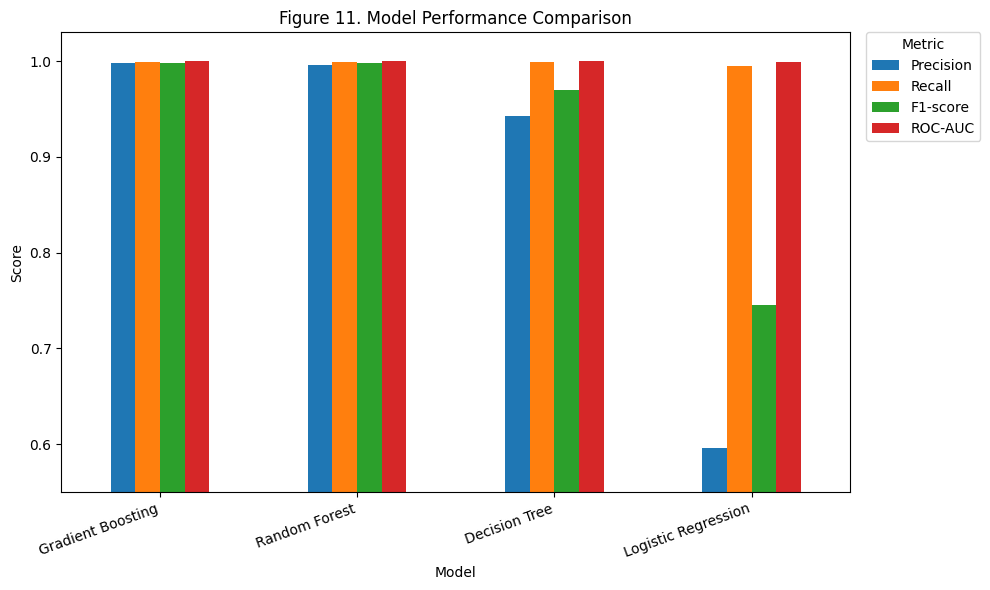

In [18]:
# I create a cleaner model comparison figure for the final report

comparison_plot = comparison_df.set_index("Model")[["Precision", "Recall", "F1-score", "ROC-AUC"]]

ax = comparison_plot.plot(kind="bar", figsize=(10, 6))

plt.title("Figure 11. Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0.55, 1.03)
plt.xticks(rotation=20, ha="right")

# I move the legend outside so it does not cover the bars
plt.legend(
    title="Metric",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0
)

plt.tight_layout()

clean_fig_path = os.path.join(output_dir, "figure_11_model_performance_comparison_clean.png")
plt.savefig(clean_fig_path, dpi=300, bbox_inches="tight")
print(f"Saved clean Figure 11 to: {clean_fig_path}")

plt.show()

In [19]:
# I create a small final prediction sample for the appendix

# I take a small sample from the test set and add final model predictions
prediction_sample = X_test.copy()
prediction_sample["Actual_isFraud"] = y_test.values
prediction_sample["Fraud_probability"] = gb_proba
prediction_sample["Predicted_isFraud"] = final_pred

# Show a mix of highest-risk and normal transactions
high_risk_examples = prediction_sample.sort_values(
    by="Fraud_probability",
    ascending=False
).head(10)

low_risk_examples = prediction_sample.sort_values(
    by="Fraud_probability",
    ascending=True
).head(10)

appendix_prediction_sample = pd.concat(
    [high_risk_examples, low_risk_examples],
    axis=0
).reset_index(drop=True)

# Keep only the most useful columns for reporting
important_prediction_columns = [
    "step",
    "amount",
    "oldbalanceOrg",
    "newbalanceOrig",
    "oldbalanceDest",
    "newbalanceDest",
    "orig_balance_error",
    "dest_balance_error",
    "amount_to_oldbalanceOrg",
    "amount_to_oldbalanceDest",
    "high_value_transaction",
    "type_CASH_OUT",
    "type_TRANSFER",
    "Actual_isFraud",
    "Fraud_probability",
    "Predicted_isFraud"
]

appendix_prediction_sample = appendix_prediction_sample[important_prediction_columns]

print("Appendix prediction sample:")
display(appendix_prediction_sample.round(4))

prediction_sample_path = os.path.join(output_dir, "table_appendix_prediction_sample.csv")
appendix_prediction_sample.to_csv(prediction_sample_path, index=False)

print(f"Saved appendix prediction sample to: {prediction_sample_path}")

Appendix prediction sample:


,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,orig_balance_error,dest_balance_error,amount_to_oldbalanceOrg,amount_to_oldbalanceDest,high_value_transaction,type_CASH_OUT,type_TRANSFER,Actual_isFraud,Fraud_probability,Predicted_isFraud
0,631,2391612.36,2391612.36,0.00,7064207.13,9455819.49,0.00,0.00,1.0000,0.3386,1,True,False,1,0.9994,1
1,370,310726.29,310726.29,0.00,1270319.48,1581045.77,0.00,0.00,1.0000,0.2446,0,True,False,1,0.9994,1
2,434,1307156.17,1307156.17,0.00,273026.12,1580182.28,0.00,0.01,1.0000,4.7876,1,True,False,1,0.9994,1
3,523,921894.19,921894.19,0.00,523285.83,1445180.02,0.00,0.00,1.0000,1.7617,1,True,False,1,0.9994,1
4,381,102256.57,102256.57,0.00,0.00,102256.57,0.00,0.00,1.0000,102256.5700,0,True,False,1,0.9994,1
5,196,436035.29,436035.29,0.00,0.00,436035.29,0.00,0.00,1.0000,436035.2900,0,True,False,1,0.9994,1
6,508,218350.42,218350.42,0.00,0.00,0.00,0.00,218350.42,1.0000,218350.4200,0,False,True,1,0.9994,1
7,634,215299.28,215299.28,0.00,0.00,0.00,0.00,215299.28,1.0000,215299.2800,0,False,True,1,0.9994,1
8,9,1154353.99,1154353.99,0.00,162222.00,1965587.60,0.00,-649011.61,1.0000,7.1158,1,True,False,1,0.9994,1
9,481,130668.56,130668.56,0.00,0.00,0.00,0.00,130668.56,1.0000,130668.5600,0,False,True,1,0.9994,1


Saved appendix prediction sample to: fraud_detection_outputs\table_appendix_prediction_sample.csv


In [20]:
# I create a final summary of the full project outputs

summary_items = {
    "Original dataset rows": df.shape[0],
    "Original dataset columns": df.shape[1],
    "Original fraud cases": int(df["isFraud"].sum()),
    "Original fraud rate (%)": round(df["isFraud"].mean() * 100, 4),
    "Modelling sample rows": model_sample.shape[0],
    "Training rows": X_train.shape[0],
    "Test rows": X_test.shape[0],
    "Final selected model": "Gradient Boosting",
    "Final decision threshold": final_threshold,
    "Final accuracy": float(final_results["Accuracy"].iloc[0]),
    "Final precision": float(final_results["Precision"].iloc[0]),
    "Final recall": float(final_results["Recall"].iloc[0]),
    "Final F1-score": float(final_results["F1-score"].iloc[0]),
    "Final ROC-AUC": float(final_results["ROC-AUC"].iloc[0]),
    "Unused legitimate validation size": unused_validation_size,
    "False positives on unused legitimate validation": false_positives_unused
}

project_summary_df = pd.DataFrame(
    list(summary_items.items()),
    columns=["Item", "Value"]
)

print("Final project summary:")
display(project_summary_df)

summary_path = os.path.join(output_dir, "table_final_project_summary.csv")
project_summary_df.to_csv(summary_path, index=False)

print(f"Saved final project summary to: {summary_path}")

print("\nSaved output files:")
saved_files = sorted(os.listdir(output_dir))

for file in saved_files:
    print(file)

Final project summary:


,Item,Value
0,Original dataset rows,6362620
1,Original dataset columns,11
2,Original fraud cases,8213
3,Original fraud rate (%),0.1291
4,Modelling sample rows,308213
5,Training rows,246570
6,Test rows,61643
7,Final selected model,Gradient Boosting
8,Final decision threshold,0.95
9,Final accuracy,1.0


Saved final project summary to: fraud_detection_outputs\table_final_project_summary.csv

Saved output files:
figure_10_fraud_across_time_steps.png
figure_11_model_performance_comparison.png
figure_11_model_performance_comparison_clean.png
figure_12_logistic_regression_confusion_matrix.png
figure_13_decision_tree_confusion_matrix.png
figure_14_random_forest_confusion_matrix.png
figure_15_gradient_boosting_confusion_matrix.png
figure_16_gradient_boosting_feature_importance.png
figure_17_roc_curve_comparison.png
figure_18_precision_recall_curve_comparison.png
figure_19_gradient_boosting_threshold_analysis.png
figure_1_target_class_distribution.png
figure_20_final_gradient_boosting_confusion_matrix.png
figure_2_transaction_type_distribution.png
figure_3_fraud_by_transaction_type.png
figure_4_fraud_rate_by_transaction_type.png
figure_5_amount_distribution_by_fraud_class.png
figure_6_correlation_heatmap.png
figure_7_mean_amount_by_fraud_class.png
figure_8_sender_zero_after_transaction.png
fi